In [4]:
#IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, matthews_corrcoef, balanced_accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold, RandomizedSearchCV, cross_validate
from sklearn.inspection import partial_dependence
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import StandardScaler


In [5]:
# Load the data
df = pd.read_csv("../data/processed/06_clr_healthy_data.csv")

# Biologically-driven 3-Class Lifestyle mapping
lifestyle_map = {
    # Class 1: Western / Highly Industrialized
    'Austria': 'Western', 'Denmark': 'Western', 'France': 'Western', 
    'Germany': 'Western', 'Italy': 'Western', 'Luxembourg': 'Western', 
    'Spain': 'Western', 'Sweden': 'Western', 'UK': 'Western', 
    'USA': 'Western', 'Finland': 'Western',
    
    # Class 2: Traditional / Rural
    'Fiji': 'Non-Western', 'Madagascar': 'Non-Western', 'Mongolia': 'Non-Western', 
    'Peru': 'Non-Western', 'Tanzania': 'Non-Western',
    
    # Class 3: Transitioning / Distinct Asian
    'China': 'Transitioning', 'India': 'Transitioning', 
    'Japan': 'Transitioning', 'Thailand': 'Transitioning'
}

# Apply the new map
df['Lifestyle'] = df['Geography'].map(lifestyle_map)

# Isolate features and target
X = df[[col for col in df.columns if col.startswith('msp')]]

# Keep the labels as strings, scikit-learn will automatically handle the multiclass labels
y = df['Lifestyle'] 

groups = df['Geography']

In [6]:
# --- 0. All Required Imports ---
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, cross_validate, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# --- Define the missing metrics variable ---
# Since you used 'roc_auc_ovr' in the inner loop (which implies multiclass classification), 
# we will use compatible metrics for the outer loop.
metrics = ['roc_auc_ovr', 'accuracy', 'f1_macro', 'balanced_accuracy']
# 1. Update Folds to 4 (to accommodate your 4 'Transitioning' countries)
n_folds = 4 
inner_cv = StratifiedGroupKFold(n_splits=n_folds)
outer_cv = StratifiedGroupKFold(n_splits=n_folds)

# 2. Refined Pipeline for Speed
pipeline = Pipeline([
    ('var_filter', VarianceThreshold()), 
    ('scaler', StandardScaler()), 
    ('lasso_selector', SelectFromModel(
        LogisticRegression(
            penalty='l1',          
            solver='saga',         
            max_iter=100,      # Reduced for speed
            tol=0.1,           # Increased tolerance for faster convergence
            class_weight='balanced', 
            random_state=42
        )
    )),
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=1))
], memory=None)

# 3. Targeted Param Grid
param_grid = {
    'var_filter__threshold': [0, 0.001], # Removed middle option
    'lasso_selector__estimator__C': [0.1, 1.0], 
    'rf__n_estimators': [100, 200], # Dropped 300 for the fast run
    'rf__max_depth': [10, None]
}

rf_search = RandomizedSearchCV(
    estimator=pipeline, 
    param_distributions=param_grid, 
    n_iter=5,          # Keep this low for testing
    cv=inner_cv, 
    scoring='roc_auc_ovr', 
    n_jobs=1,          # Let the outer loop handle parallelization
    random_state=42
)

# 4. Run Outer CV
# Note: Ensure that X, y, and groups are defined in your environment before running this!
results = cross_validate(
    rf_search, 
    X, 
    y, 
    groups=groups, 
    cv=outer_cv, 
    scoring=metrics,   # <--- The defined metrics are now successfully passed here
    n_jobs=-1,         # This will run 4 folds in parallel
    params={'groups': groups} 
)

# Print the results so you can see how it performed
print("Mean ROC AUC OVR:", results['test_roc_auc_ovr'].mean())
print("Mean Accuracy:", results['test_accuracy'].mean())

/Users/ajnabinaki/Documents/Repositories/FS 26/PA-richtig/PA1_repo2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ajnabinaki/Documents/Repositories/FS 26/PA-richtig/PA1_repo2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/ajnabinaki/Documents/Repositories/FS 26/PA-richtig/PA1_repo2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set 

Mean ROC AUC OVR: 0.9193148243030648
Mean Accuracy: 0.7367929283459782


/Users/ajnabinaki/Documents/Repositories/FS 26/PA-richtig/PA1_repo2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ajnabinaki/Documents/Repositories/FS 26/PA-richtig/PA1_repo2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/ajnabinaki/Documents/Repositories/FS 26/PA-richtig/PA1_repo2/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set 

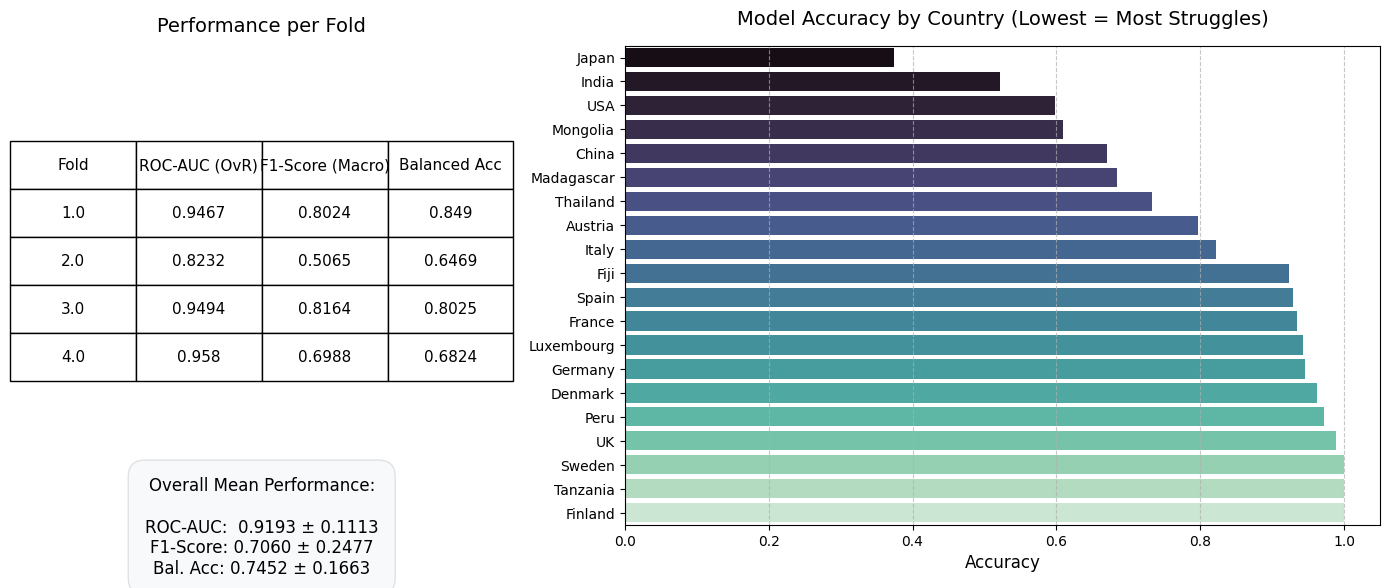

In [7]:
# 1. Generate out-of-fold predictions (No changes needed here!)
y_pred = cross_val_predict(
    rf_search, 
    X, 
    y, 
    groups=groups, 
    cv=outer_cv, 
    n_jobs=-1,
    params={'groups': groups} 
)

# 2. Prepare the data
# THE FIX: Updated the dictionary keys to match the multiclass metrics
fold_summary = pd.DataFrame({
    'Fold': range(1, outer_cv.n_splits + 1),
    'ROC-AUC (OvR)': results['test_roc_auc_ovr'],     # <-- Changed
    'F1-Score (Macro)': results['test_f1_macro'],     # <-- Changed
    'Balanced Acc': results['test_balanced_accuracy']
})

# This works perfectly for multiclass as-is
analysis_df = pd.DataFrame({'Country': groups, 'Correct': y == y_pred})
country_accuracy = analysis_df.groupby('Country')['Correct'].mean().sort_values()

# 3. Create a unified visual dashboard
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 1.5]})

# --- Left Panel: Metrics Table ---
ax1.axis('off')
ax1.set_title("Performance per Fold", fontsize=14, pad=10)

# Add the dataframe as a table
table = ax1.table(
    cellText=fold_summary.round(4).values,
    colLabels=fold_summary.columns,
    loc='center', 
    cellLoc='center',
    bbox=[0.0, 0.3, 1.0, 0.5]
)
table.auto_set_font_size(False)
table.set_fontsize(11)

# Add overall summary text below the table
# THE FIX: Updated keys here as well
summary_text = (
    f"Overall Mean Performance:\n\n"
    f"ROC-AUC:  {results['test_roc_auc_ovr'].mean():.4f} ± {results['test_roc_auc_ovr'].std()*2:.4f}\n" # <-- Changed
    f"F1-Score: {results['test_f1_macro'].mean():.4f} ± {results['test_f1_macro'].std()*2:.4f}\n"   # <-- Changed
    f"Bal. Acc: {results['test_balanced_accuracy'].mean():.4f} ± {results['test_balanced_accuracy'].std()*2:.4f}"
)
ax1.text(0.5, 0.1, summary_text, ha='center', va='top', fontsize=12, 
         bbox=dict(boxstyle='round,pad=1', facecolor='#f8f9fa', edgecolor='#dee2e6'))

# --- Right Panel: Country Accuracy Plot --- (No changes needed here!)
sns.barplot(x=country_accuracy.values, y=country_accuracy.index, palette="mako", ax=ax2)
ax2.set_title("Model Accuracy by Country (Lowest = Most Struggles)", fontsize=14, pad=15)
ax2.set_xlabel("Accuracy", fontsize=12)
ax2.set_ylabel("") 
ax2.set_xlim(0, 1.05)
ax2.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()